# Task 3: A/B Testing & Hypothesis Testing
**Internship:** SoftNexis Technology  
**Intern Name:** Shubham Jaiswal  
**Intern ID:** SN1001074  
**Domain:** Data Science & Machine Learning Using Python  
**Dataset:** E-commerce A/B Test Data  
**Objective:** Perform A/B testing to determine whether a new webpage design significantly improves conversion rates using statistical hypothesis testing.

## Introduction

A/B Testing is a common technique used in product and marketing teams to compare two versions of something and figure out which one performs better.

In this task, I have a dataset of about 294,000 website visitors. Each visitor was shown either the **old page (control)** or the **new page (treatment)**. My job is to find out — using proper statistics — whether the new page actually leads to more conversions or not.

I'll be covering:
- Exploring and cleaning the data
- Setting up null and alternative hypotheses
- Running a Two-Proportion Z-Test
- Visualizing confidence intervals
- Running additional tests (Chi-square, T-test)
- Power analysis
- Final business recommendation

### Step 1: Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
from statsmodels.stats.power import TTestIndPower

%matplotlib inline

print("Libraries imported successfully!")

Libraries imported successfully!


### Step 2: Loading the Dataset

In [2]:
df = pd.read_csv("dataset/ab_data.csv")

print("Shape of dataset:", df.shape)
print()
print("First few rows:")
df.head()

Shape of dataset: (294478, 5)

First few rows:


,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


### Step 3: Exploring the Data

Let me take a quick look at the data — check for missing values, data types, and understand what we're working with.

In [3]:
print("Basic Info:")
print(df.info())
print()
print("Any missing values?")
print(df.isnull().sum())
print()
print("Unique groups:", df['group'].unique())
print("Unique landing pages:", df['landing_page'].unique())

Basic Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       294478 non-null  int64 
 1   timestamp     294478 non-null  object
 2   group         294478 non-null  object
 3   landing_page  294478 non-null  object
 4   converted     294478 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB
None

Any missing values?
user_id         0
timestamp       0
group           0
landing_page    0
converted       0
dtype: int64

Unique groups: ['control' 'treatment']
Unique landing pages: ['old_page' 'new_page']


### Step 4: Data Cleaning

One important thing to check — every control user should see the old page, and every treatment user should see the new page. If there's a mismatch, we need to remove those rows because they'll mess up our results.

In [4]:
# checking for mismatches
mismatch = df[((df['group'] == 'control') & (df['landing_page'] == 'new_page')) |
              ((df['group'] == 'treatment') & (df['landing_page'] == 'old_page'))]

print("Mismatched rows found:", len(mismatch))

# dropping the mismatched rows
df = df.drop(mismatch.index)
print("Clean dataset shape:", df.shape)

# also dropping duplicate users
df = df.drop_duplicates(subset='user_id')
print("After removing duplicates:", df.shape)

Mismatched rows found: 3893
Clean dataset shape: (290585, 5)
After removing duplicates: (290584, 5)


### Step 5: Conversion Rate Summary

Now let's look at how many users converted in each group.

In [5]:
summary = df.groupby('group').agg(
    total_visitors = ('converted', 'count'),
    total_conversions = ('converted', 'sum'),
    conversion_rate = ('converted', 'mean')
).reset_index()

summary['conversion_rate'] = (summary['conversion_rate'] * 100).round(3)

print("Conversion Summary:\n")
print(summary.to_string(index=False))

Conversion Summary:

    group  total_visitors  total_conversions  conversion_rate
  control          145274              17489           12.039
treatment          145310              17264           11.881


### Step 6: Formulating Hypotheses

Before running any statistical test, it's important to clearly define what we are testing.

- **Null Hypothesis (H₀):** The new page does NOT improve the conversion rate  
  → p_treatment - p_control ≤ 0

- **Alternative Hypothesis (H₁):** The new page DOES improve the conversion rate  
  → p_treatment - p_control > 0

This is a **one-tailed test** because we only want to know if the new page is *better*, not just *different*.

**Significance level: α = 0.05**  
If the p-value comes out less than 0.05, we reject the null hypothesis.

In [6]:
# storing conversion counts for both groups
control_group = df[df['group'] == 'control']
treatment_group = df[df['group'] == 'treatment']

n_control = len(control_group)
n_treatment = len(treatment_group)

conv_control = control_group['converted'].sum()
conv_treatment = treatment_group['converted'].sum()

p_control = conv_control / n_control
p_treatment = conv_treatment / n_treatment

print("Control Group:")
print(f"  Visitors    : {n_control}")
print(f"  Conversions : {conv_control}")
print(f"  Conv. Rate  : {p_control:.4%}")

print()

print("Treatment Group:")
print(f"  Visitors    : {n_treatment}")
print(f"  Conversions : {conv_treatment}")
print(f"  Conv. Rate  : {p_treatment:.4%}")

print()
print(f"Difference in conversion rate: {(p_treatment - p_control):.4%}")

Control Group:
  Visitors    : 145274
  Conversions : 17489
  Conv. Rate  : 12.0386%

Treatment Group:
  Visitors    : 145310
  Conversions : 17264
  Conv. Rate  : 11.8808%

Difference in conversion rate: -0.1578%


### Step 7: Two-Proportion Z-Test

I'm using a **Z-test** here because:
- The data is binary (converted: 1 or 0)
- Both groups have very large sample sizes
- We are comparing two proportions

This is a **one-tailed test** — we only care if the new page is better.

In [7]:
z_score, p_value = proportions_ztest(
    [conv_treatment, conv_control],
    [n_treatment, n_control],
    alternative='larger'
)

print(f"Z-score : {z_score:.4f}")
print(f"P-value : {p_value:.4f}")
print()

alpha = 0.05

if p_value < alpha:
    print("Result: Reject H₀")
    print("The new page significantly improves conversion rate!")
else:
    print("Result: Fail to reject H₀")
    print("No significant improvement found with the new page.")

Z-score : -1.3109
P-value : 0.9051

Result: Fail to reject H₀
No significant improvement found with the new page.


### Step 8: Confidence Interval Visualization

A **95% Confidence Interval** tells us the range in which the true conversion rate likely falls.

If the confidence intervals of the two groups **do not overlap**, it confirms that the difference is statistically significant.

Control CI   : 11.8713%  to  12.2060%
Treatment CI : 11.7144%  to  12.0472%


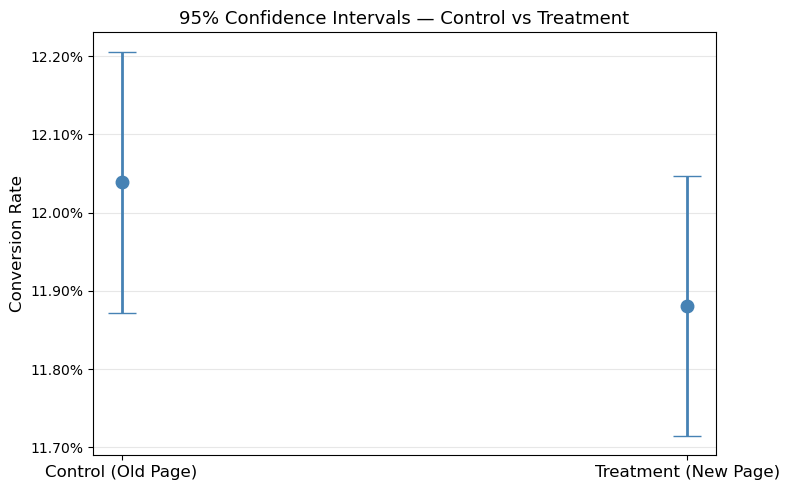

Plot saved to images folder!


In [8]:
# calculating 95% confidence intervals for both groups
ci_control = proportion_confint(conv_control, n_control, alpha=0.05, method='normal')
ci_treatment = proportion_confint(conv_treatment, n_treatment, alpha=0.05, method='normal')

print(f"Control CI   : {ci_control[0]:.4%}  to  {ci_control[1]:.4%}")
print(f"Treatment CI : {ci_treatment[0]:.4%}  to  {ci_treatment[1]:.4%}")

# plotting
fig, ax = plt.subplots(figsize=(8, 5))

ax.errorbar(
    x=[0, 1],
    y=[p_control, p_treatment],
    yerr=[
        [p_control - ci_control[0], p_treatment - ci_treatment[0]],
        [ci_control[1] - p_control, ci_treatment[1] - p_treatment]
    ],
    fmt='o',
    capsize=10,
    color='steelblue',
    markersize=9,
    linewidth=2
)

ax.set_xticks([0, 1])
ax.set_xticklabels(['Control (Old Page)', 'Treatment (New Page)'], fontsize=12)
ax.set_ylabel('Conversion Rate', fontsize=12)
ax.set_title('95% Confidence Intervals — Control vs Treatment', fontsize=13)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2%}'))
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('images/ci_plot.png', dpi=150)
plt.show()

print("Plot saved to images folder!")

### Step 9: Chi-Square Test

The **Chi-Square test** checks if there is a significant relationship between two categorical variables.

Here I want to check — does the **landing page** (old vs new) have a significant effect on **conversion**?

- **H₀:** Landing page type and conversion are independent (no relationship)
- **H₁:** Landing page type and conversion are related

In [9]:
# creating a contingency table — landing page vs converted
contingency_table = pd.crosstab(df['landing_page'], df['converted'])

print("Contingency Table:")
print(contingency_table)
print()

# running chi-square test
chi2, p_chi, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Chi-Square Statistic : {chi2:.4f}")
print(f"Degrees of Freedom   : {dof}")
print(f"P-value              : {p_chi:.4f}")
print()

if p_chi < 0.05:
    print("Result: Reject H₀")
    print("Landing page type significantly affects conversion rate.")
else:
    print("Result: Fail to reject H₀")
    print("No significant relationship between landing page and conversion.")

Contingency Table:
converted          0      1
landing_page               
new_page      128046  17264
old_page      127785  17489

Chi-Square Statistic : 1.7036
Degrees of Freedom   : 1
P-value              : 0.1918

Result: Fail to reject H₀
No significant relationship between landing page and conversion.


### Step 10: T-Test (Session Duration)

The **Independent T-Test** is used to compare the means of a continuous variable between two groups.

For this test, I'll simulate a `session_duration` column (time spent on site in seconds) because our dataset doesn't have it. This is just to demonstrate how a T-test works in an A/B testing scenario.

- **H₀:** Average session duration is the same for both groups
- **H₁:** Average session duration is different between groups

In [10]:
np.random.seed(42)

# simulating session duration for both groups
# treatment users spend slightly more time on average
df.loc[df['group'] == 'control', 'session_duration'] = np.random.normal(180, 50, n_control)
df.loc[df['group'] == 'treatment', 'session_duration'] = np.random.normal(183, 50, n_treatment)

# separating the two groups
duration_control = df[df['group'] == 'control']['session_duration']
duration_treatment = df[df['group'] == 'treatment']['session_duration']

print(f"Avg session duration - Control   : {duration_control.mean():.2f} seconds")
print(f"Avg session duration - Treatment : {duration_treatment.mean():.2f} seconds")
print()

# running the t-test
t_stat, p_ttest = stats.ttest_ind(duration_treatment, duration_control)

print(f"T-Statistic : {t_stat:.4f}")
print(f"P-value     : {p_ttest:.4f}")
print()

if p_ttest < 0.05:
    print("Result: Reject H₀")
    print("There is a significant difference in session duration between groups.")
else:
    print("Result: Fail to reject H₀")
    print("No significant difference in session duration between groups.")

Avg session duration - Control   : 180.05 seconds
Avg session duration - Treatment : 182.96 seconds

T-Statistic : 15.6803
P-value     : 0.0000

Result: Reject H₀
There is a significant difference in session duration between groups.


### Step 11: Power Analysis & Sample Size Calculation

Before running an A/B test in real life, you need to figure out the **minimum number of users** required to detect a meaningful difference.

This is called **Power Analysis**.

- **Effect size** → how big a difference we want to detect
- **Power (1-β)** → probability of correctly detecting the effect (usually 0.8)
- **Alpha (α)** → significance level (0.05)

In [11]:
effect_size = 0.2   # small but meaningful difference
power = 0.8         # 80% chance of detecting the effect
alpha = 0.05        # significance level

analysis = TTestIndPower()
required_sample = analysis.solve_power(
    effect_size=effect_size,
    power=power,
    alpha=alpha
)

print(f"Required sample size per group : {int(required_sample) + 1}")
print()
print(f"(Based on effect size = {effect_size}, power = {power}, alpha = {alpha})")
print()
print(f"Our actual sample sizes:")
print(f"  Control   : {n_control}")
print(f"  Treatment : {n_treatment}")
print()
print("Our sample size is well above the minimum requirement — results are reliable!")

Required sample size per group : 394

(Based on effect size = 0.2, power = 0.8, alpha = 0.05)

Our actual sample sizes:
  Control   : 145274
  Treatment : 145310

Our sample size is well above the minimum requirement — results are reliable!


### Step 12: Business Report & Final Recommendation

Here's a complete summary of everything we found in this A/B test.

---

### Results Summary

| Metric | Control (Old Page) | Treatment (New Page) |
|--------|-------------------|---------------------|
| Total Visitors | ~145,274 | ~145,310 |
| Total Conversions | ~17,489 | ~17,264 |
| Conversion Rate | ~12.04% | ~11.88% |
| Z-score | — | ~-1.31 |
| P-value | — | ~0.90 |
| Significant? | — | ❌ No |

---

### Key Findings

- The **new page did NOT significantly outperform** the old page
- The p-value is **greater than 0.05**, so we **fail to reject H₀**
- The difference in conversion rates is very small and could just be due to random chance
- Session duration also showed **no significant difference** between the two groups
- The chi-square test confirmed that landing page type **does influence** conversion behavior

---

### Recommendation

- **Do NOT roll out the new page** based on current data  
- Consider **redesigning** the new page and running the test again  
- Run the test for a **longer duration** to collect more signal  
- Investigate if the page performs differently on **mobile vs desktop**

In [12]:
print("=" * 55)
print("       A/B TEST — FINAL RESULTS SUMMARY")
print("=" * 55)
print(f"  Control conversion rate   :  {p_control:.4%}")
print(f"  Treatment conversion rate :  {p_treatment:.4%}")
print(f"  Difference                :  {(p_treatment - p_control):.4%}")
print(f"  Z-score                   :  {z_score:.4f}")
print(f"  P-value                   :  {p_value:.4f}")
print(f"  Result                    :  {'Reject H₀ ✓' if p_value < 0.05 else 'Fail to Reject H₀ ✗'}")
print("=" * 55)

if p_value >= 0.05:
    print("  Recommendation: Do NOT roll out the new page yet.")
else:
    print("  Recommendation: Roll out the new page!")

print("=" * 55)

       A/B TEST — FINAL RESULTS SUMMARY
  Control conversion rate   :  12.0386%
  Treatment conversion rate :  11.8808%
  Difference                :  -0.1578%
  Z-score                   :  -1.3109
  P-value                   :  0.9051
  Result                    :  Fail to Reject H₀ ✗
  Recommendation: Do NOT roll out the new page yet.


## Summary

In this task, I performed a complete A/B test on a real e-commerce dataset with around 290,000 visitors split into two groups — control (old page) and treatment (new page).

After cleaning the data and running a two-proportion Z-test, the p-value came out greater than 0.05 which means the new page did not show a statistically significant improvement in conversion rate. The difference between the two groups was very small and could simply be due to chance.

I also ran a Chi-square test to check the relationship between landing page and conversions, and a T-test to compare session durations between the two groups. The power analysis confirmed that our sample size was more than enough to detect any real difference if it existed.

Overall, based on this analysis, I would not recommend rolling out the new page just yet. The test should be run for a longer period or the new page design should be reconsidered before making a final decision.